# Линейная регрессия

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from model import NeuralNetwork
from utils import *

X = np.linspace(-10, 10, 100).reshape(-1, 1)
y = 2 * X + 1


X = np.array(X)
y = np.array(y)

X_train, y_train, X_test, y_test = X[:int(len(X) * (7 / 10))],  \
                                    y[:int(len(X) * (7 / 10))], \
                                    X[int(len(X) * (7 / 10)):], \
                                    y[int(len(X) * (7 / 10)):]

nn = NeuralNetwork(layer_sizes=[1, 8, 1], task='regression', lr=0.01)
nn.train(X_train, y_train, epochs=1000, batch_size=16)

y_pred = nn.predict(X_test)


print(f"MSE {mse_metric(y_test, y_pred)}")
print(f"RMSE {rmse_metric(y_test, y_pred)}")
print(f"MAE {mae_metric(y_test, y_pred)}")
print(f"MAPE {mape_metric(y_test, y_pred)}")

plt.plot(X_test, y_test, '-o')
plt.plot(X_test, y_pred)
plt.show()

# Нелинейная регрессия

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from model import NeuralNetwork
from utils import *

X = np.linspace(-5, 5, 100).reshape(-1, 1)
y = np.sin(X)
y += np.random.normal(0, 0.05, size=y.shape)

X = np.array(X)
y = np.array(y)

X = z_score_normalizer(X)
y = z_score_normalizer(y)

split_idx = int(len(X) * 0.7)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

nn = NeuralNetwork(layer_sizes=[1, 128, 128, 1], task='regression', lr=0.001, init_method='he', activation='tanh')
nn.train(X_train, y_train, epochs=5000, batch_size=32)

y_pred = nn.predict(X_test)

y_pred = y_pred * np.std(y) + np.mean(y)
y_test = y_test * np.std(y) + np.mean(y)

print(f"MSE {mse_metric(y_test, y_pred)}")
print(f"RMSE {rmse_metric(y_test, y_pred)}")
print(f"MAE {mae_metric(y_test, y_pred)}")
print(f"MAPE {mape_metric(y_test, y_pred)}")

plt.plot(X_test, y_test, '-o')
plt.plot(X_test, y_pred)
plt.show()

# Регрессия (дома)

In [ ]:
import numpy as np
import pandas as pd
from utils import *
from model import NeuralNetwork

train_df = pd.read_csv("./data/train_reg.csv")

y = z_score_normalizer(np.array(train_df["SalePrice"]))
X = train_df.drop(["Id", "SalePrice"], axis=1)
X = X.select_dtypes(include=['float64', 'int64']).fillna(0)
X = z_score_normalizer(X)

X = np.array(X)
y = np.array(y)

split_idx = int(len(X) * 0.7)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

y_train = y_train.reshape(-1, 1)

nn = NeuralNetwork(layer_sizes=[X_train.shape[1], 16, 1], task='regression', lr=0.01)
nn.train(X_train, y_train, epochs=2000, batch_size=16)

y_p = nn.predict(X_test)

print(f"MSE {mse_metric(y_test, y_p)}")
print(f"RMSE {rmse_metric(y_test, y_p)}")
print(f"MAE {mae_metric(y_test, y_p)}")
print(f"MAPE {mape_metric(y_test, y_p)}")

plt.scatter(y_test, y_p, 2)
plt.plot(y_p, y_p, "r")
plt.show()

# Классификация (Титаник)

In [ ]:
import pandas as pd
import numpy as np
from utils import *
from model import NeuralNetwork

data = pd.read_csv("./data/train.csv")

data = data.drop(["PassengerId", "Name", "Age", "Ticket", "Fare", "Cabin"],axis=1)
data = pd.get_dummies(data=data, columns=['Sex', 'Embarked'], prefix=['sex', 'embarked'])

X = data.drop('Survived',axis=1)
y = data['Survived']

X = np.array(X)
y = np.array(y).reshape(-1, 1)

split_idx = int(len(X) * 0.7)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)
X_test = X_test.astype(np.float32)

nn = NeuralNetwork(layer_sizes=[X_train.shape[1], 32, 1], task='binary_classification', lr=0.01)
nn.train(X_train, y_train, epochs=2000, batch_size=8)

y_pred = nn.predict(X_test)

print("Accuracy: {}".format(accuracy(np.array(y_test), y_pred)))
print("Avg harmonical: {}".format(avg_harmonical(np.array(y_test), y_pred)))
print("Recall: {}".format(recall(np.array(y_test), y_pred)))
print("Precision: {}".format(precision(np.array(y_test), y_pred)))

# Мультиклассовая классификация (MNIST)

In [ ]:
import pandas as pd
import numpy as np
from utils import *
from model import NeuralNetwork
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, StandardScaler

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, parser='auto')
X = X / 255.0
y = LabelBinarizer().fit_transform(y)

X_train, y_train, X_test, y_test = X[:int(len(X) * (7 / 10))],  \
                                    y[:int(len(X) * (7 / 10))], \
                                    X[int(len(X) * (7 / 10)):], \
                                    y[int(len(X) * (7 / 10)):]

X_train = np.array(X_train)
y_train = np.array(y_train)
nn = NeuralNetwork(layer_sizes=[784, 128, 64, 10], task='multiclass_classification', lr=0.01)
nn.train(X_train, y_train, epochs=10, batch_size=128)

y_pred = nn.predict(X_test)

y_test = np.argmax(y_test, axis=1)

print("Accuracy: {}".format(accuracy(np.array(y_test), y_pred)))
print("Avg harmonical: {}".format(avg_harmonical(np.array(y_test), y_pred)))
print("Recall: {}".format(recall(np.array(y_test), y_pred)))
print("Precision: {}".format(precision(np.array(y_test), y_pred)))

---

# PL Линейная задача

In [ ]:
from model import *
from utils import *
import matplotlib.pyplot as plt

dataset = LinearDataset()
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

trainer = pl.Trainer(max_epochs=50)
model = LinearModel()
trainer.fit(model, train_loader, val_loader)

model.eval()
with torch.no_grad():
    x_test = np.linspace(0, 10, 100).reshape(-1, 1).astype(np.float32)
    y_pred = model(torch.from_numpy(x_test)).numpy()
    y_true = x_test

plt.figure(figsize=(10, 6))
plt.scatter(dataset.x, dataset.y, label='Данные', alpha=0.5)
plt.plot(x_test, y_pred, 'r-', linewidth=2, label='Предсказание')
plt.title('Предсказание линейной зависимости')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

y_val_pred = model(torch.from_numpy(val_dataset[:][0])).detach().numpy()
y_val_true = val_dataset[:][1]
mse = mean_squared_error(y_val_true, y_val_pred)
r2 = r2_score(y_val_true, y_val_pred)
print(f'MSE: {mse:.4f}, R2: {r2:.4f}')


# PL Нелинейная задача

In [ ]:
from model import *
from utils import *
import matplotlib.pyplot as plt

dataset = SinDataset()
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

trainer = pl.Trainer(max_epochs=100)
model = SinModel()
trainer.fit(model, train_loader, val_loader)

model.eval()
with torch.no_grad():
    x_test = np.linspace(0, 10, 100).reshape(-1, 1).astype(np.float32)
    y_pred = model(torch.from_numpy(x_test)).numpy()
    y_true = np.sin(x_test)

plt.figure(figsize=(10, 6))
plt.scatter(dataset.x, dataset.y, label='Данные', alpha=0.5)
plt.plot(x_test, y_true, 'g-', linewidth=2, label='Истинная функция')
plt.plot(x_test, y_pred, 'r-', linewidth=2, label='Предсказание')
plt.title('Предсказание нелинейной зависимости')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

y_val_pred = model(torch.from_numpy(val_dataset[:][0])).detach().numpy()
y_val_true = val_dataset[:][1]
mse = mean_squared_error(y_val_true, y_val_pred)
r2 = r2_score(y_val_true, y_val_pred)
print(f'MSE: {mse:.4f}, R2: {r2:.4f}')

# PL Регрессия (дома)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | net     | Sequential | 15.1 K | train
1 | loss_fn | MSELoss    | 0      | train
-----------------------------------------------
15.1 K    Trainable params
0         Non-trainable params
15.1 K    Total params
0.060     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
C:\Users\илья\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `nu

Epoch 9: 100%|██████████| 37/37 [00:00<00:00, 152.35it/s, v_num=34]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 37/37 [00:00<00:00, 146.32it/s, v_num=34]


C:\Users\илья\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 204.72it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.15070326626300812
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


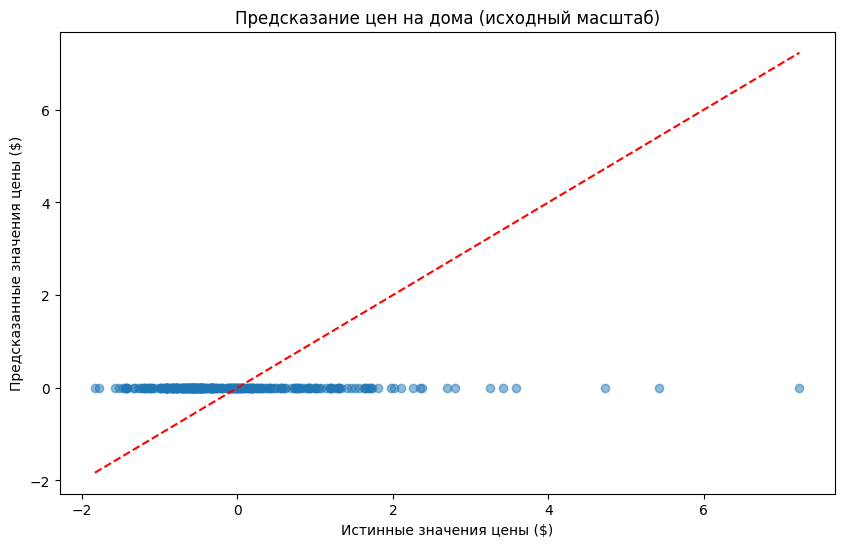

MSE: 1.2169
R2 Score: -0.0006


In [2]:
from model import *
from utils import *
import matplotlib.pyplot as plt

train_dataset = HousePricesDataset(train=True)
test_dataset = HousePricesDataset(train=False)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

input_size = len(train_dataset.get_feature_names())
model = HousePriceModel(input_size=input_size)
trainer = pl.Trainer(max_epochs=10)
trainer.fit(model, train_loader)

test_results = trainer.test(model, test_loader)[0]
predictions = model.test_predictions
targets = model.test_targets

# predictions_orig = test_dataset.inverse_transform_y(predictions)
# targets_orig = test_dataset.inverse_transform_y(targets)

plt.figure(figsize=(10, 6))
plt.scatter(targets, predictions, alpha=0.5)
plt.plot([min(targets), max(targets)], 
         [min(targets), max(targets)], 'r--')
plt.xlabel('Истинные значения цены ($)')
plt.ylabel('Предсказанные значения цены ($)')
plt.title('Предсказание цен на дома (исходный масштаб)')
plt.show()

mse = mean_squared_error(targets, predictions)
r2 = r2_score(targets, predictions)
print(f'MSE: {mse:.4f}')
print(f'R2 Score: {r2:.4f}')